# 06 · Land use & planet health

The Sustain track is **“Emissions, land use & planet health.”** Notebooks 01–05 covered emissions. This one explores the other two legs:

- **Land use** — how much land agriculture uses, and how it's shifting.
- **Planet health** — forest loss (deforestation) and cropland nutrient surplus.

Uses your existing **Land Use** file plus two optional downloads (**Land Cover**, **Cropland Nutrient Balance**). Degrades gracefully if either is absent.

## Setup

In [16]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src import load, clean, footprint, viz

data = load.load_all()
land = data['landuse']
land_c, _ = clean.split_countries_aggregates(land)
YEAR = clean.pick_analysis_year(land_c)
print('land-use year', YEAR, '| rows', len(land_c))

land-use year 2025 | rows 341611


### Discovery — what land-use items exist?
Confirm whether a **Forest land** item is present (drives the deforestation angle).

In [17]:
items = sorted(land_c['Item'].unique())
print(f'{len(items)} land-use items:')
for i in items: print('  ', i)
forest = [i for i in items if 'forest' in i.lower()]
print('\nForest items:', forest or 'NONE — use Land Cover / Forestry for deforestation')

45 land-use items:
   Agricultural land
   Agriculture
   Agriculture area actually irrigated
   Agriculture area certified organic
   Agriculture area under organic agric.
   Arable land
   Coastal waters
   Coastal waters used for aquac. or holding facilities
   Coastal waters used for capture fisheries
   Country area
   Cropland
   Cropland area actually irrigated
   Cropland area certified organic
   Cropland area under conservation tillage
   Cropland area under conventional tillage
   Cropland area under organic agric.
   Cropland area under protective cover
   Cropland area under zero or no tillage
   EEZ used for aquac. or holding facilities
   EEZ used for capture fisheries
   Exclusive Economic Zone (EEZ)
   Farm buildings and Farmyards
   Forest land
   Forestry area actually irrigated
   Inland waters
   Inland waters used for aquac. or holding facilities
   Inland waters used for capture fisheries
   Land area
   Land area actually irrigated
   Land area equipped for irri

## Leg 1 — Land use: how much land, in what

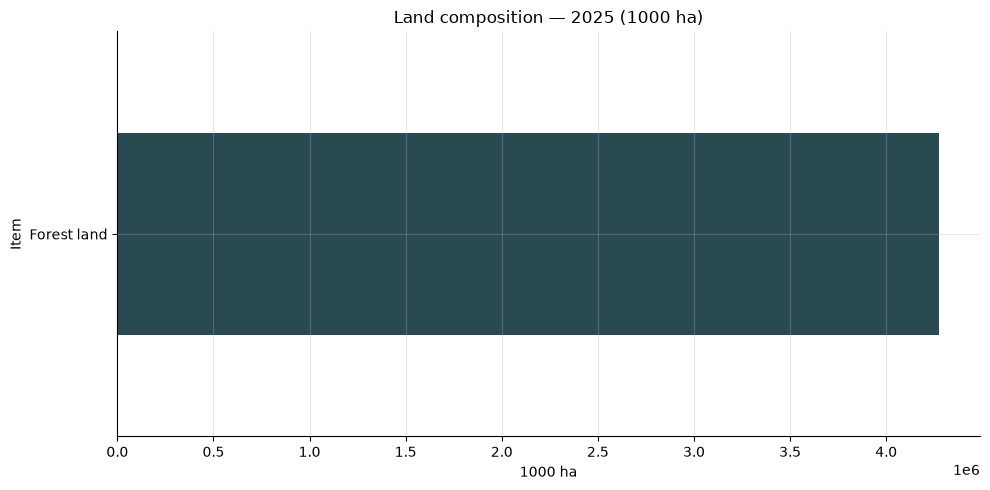

Item
Forest land    4.274401e+06
Name: Value, dtype: float64

In [18]:
# Non-overlapping top-level categories (avoids forest sub-types double-counting).
comp = footprint.land_composition(land_c, YEAR)
viz.barh_ranking(comp, f'Land composition — {YEAR} (1000 ha)', '1000 ha', n=10, color='#2A4A52'); plt.show()
comp

### Land use over time — expansion vs stability

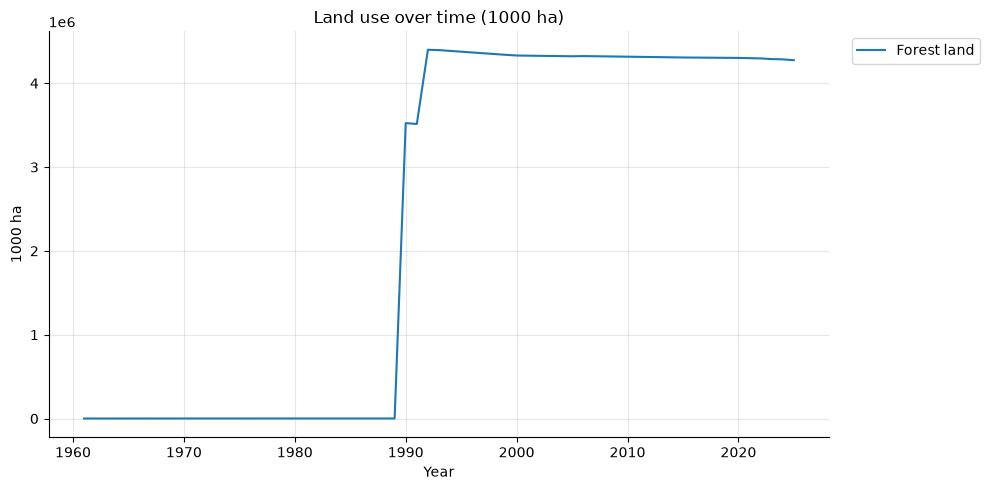

In [19]:
# Trend for the biggest agricultural land items.
focus = [i for i in comp.head(4).index]
trend = (land_c[land_c['Item'].isin(focus)].groupby(['Year','Item'])['Value'].sum().unstack())
viz.line_trends(trend, 'Land use over time (1000 ha)', '1000 ha'); plt.show()

## Leg 2 — Planet health: forest loss (deforestation)

forest item: Forest land


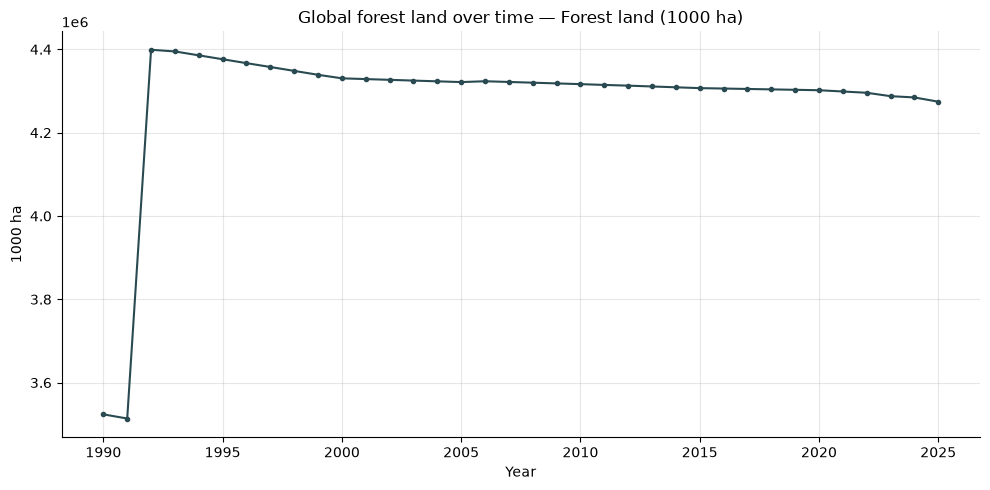

1990: 3,523,855  ->  2025: 4,274,401  (+21.3%)


In [20]:
ft, fitem = footprint.forest_trend(land_c)
if ft is not None:
    print('forest item:', fitem)
    ax = ft.plot(color='#2A4A52', marker='o', ms=3)
    ax.set_title(f'Global forest land over time — {fitem} (1000 ha)')
    ax.set_ylabel('1000 ha'); plt.tight_layout(); plt.show()
    yrs = sorted(ft.index)
    print(f'{yrs[0]}: {ft.iloc[0]:,.0f}  ->  {yrs[-1]}: {ft.iloc[-1]:,.0f}  '
          f'({100*(ft.iloc[-1]-ft.iloc[0])/ft.iloc[0]:+.1f}%)')
else:
    print('No forest item in Land Use — download Land Cover or Forestry.')

### Biggest forest losers by country

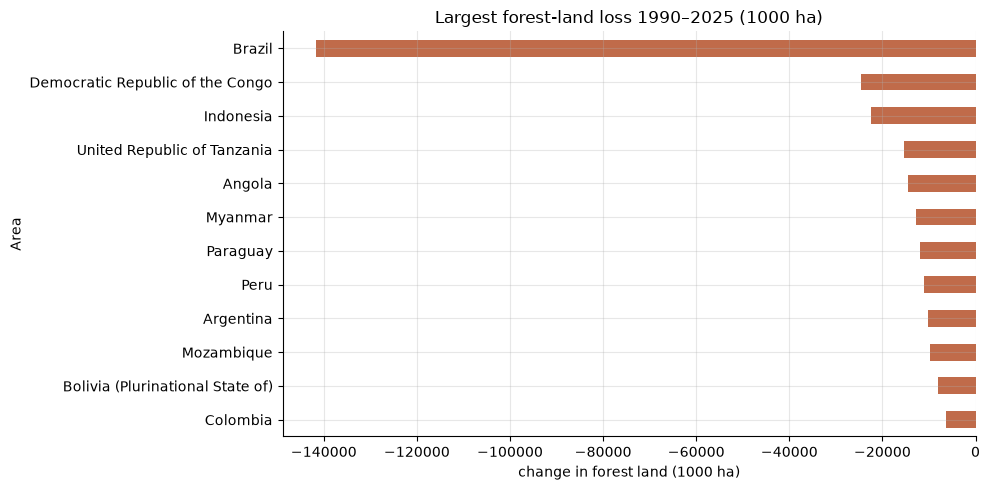

Window 1990–2025. Biggest losers:
Area
Brazil                             -141764.47
Democratic Republic of the Congo    -24607.31
Indonesia                           -22493.39
United Republic of Tanzania         -15338.58
Angola                              -14579.75
Myanmar                             -12788.00
Name: Value, dtype: float64

Biggest gainers:
Area
China              75124.67
China, mainland    75124.60
India               9887.94
Canada              6878.94
Name: Value, dtype: float64


In [21]:
ft, fitem = footprint.forest_trend(land_c)
if ft is not None:
    good_years = sorted(ft.index)
    yfrom, yto = good_years[0], good_years[-1]   # both from well-covered range
    chg, _ = footprint.forest_change_by_country(land_c, yfrom, yto, fitem)
    losers = chg.head(12)   # most negative = biggest loss
    ax = losers[::-1].plot.barh(color='#C06B4A')
    ax.set_title(f'Largest forest-land loss {yfrom}–{yto} (1000 ha)')
    ax.set_xlabel('change in forest land (1000 ha)'); plt.tight_layout(); plt.show()
    print(f'Window {yfrom}–{yto}. Biggest losers:'); print(losers.head(6))
    print('\nBiggest gainers:'); print(chg.tail(4)[::-1])
else:
    print('Needs a forest item.')

## Leg 2b — Land Cover (optional download)
Richer land-cover composition & change if the file is present.

In [22]:
lc = load.try_read('land_cover')
if lc is not None:
    lc_c, _ = clean.split_countries_aggregates(lc)
    print('Land Cover elements:', list(lc_c['Element'].unique())[:5])
    print('Land Cover items:')
    for i in sorted(lc_c['Item'].unique())[:20]: print('  ', i)
else:
    print('Download Land Cover (Environment_LandCover_E_All_Data.csv) to enable.')

Land Cover elements: ['Area from CCI_LC', 'Area from MODIS', 'Area from CGLS', 'Area from WorldCover']
Land Cover items:
   Artificial surfaces (including urban and associated areas)
   Coastal water bodies and intertidal areas
   Grassland
   Herbaceous crops
   Inland water bodies
   Mangroves
   Multiple or layered crops
   Permanent snow and glaciers
   Shrub-covered areas
   Shrubs and/or herbaceous vegetation, aquatic or regularly flooded
   Sparsely natural vegetated areas
   Terrestrial barren land
   Tree-covered areas
   Woody crops


## Leg 3 — Planet health: cropland nutrient surplus
Over-fertilization (nitrogen/phosphorus surplus) is a planet-health harm distinct from climate — it drives water pollution and soil damage.

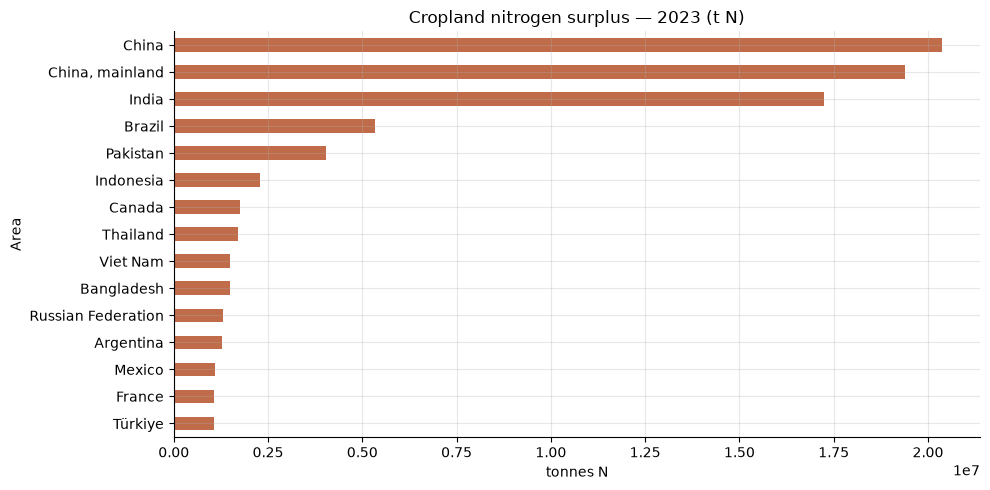

Most nitrogen surplus (t N):


Area
China              2.036095e+07
China, mainland    1.939936e+07
India              1.723094e+07
Brazil             5.323797e+06
Pakistan           4.028339e+06
Indonesia          2.283688e+06
Canada             1.752763e+06
Thailand           1.696691e+06
Viet Nam           1.492314e+06
Bangladesh         1.478897e+06
Name: Value, dtype: float64


Among significant croplands only (top-half by N input):
Least efficient N use (most waste per unit) — the lever:


Area
Mongolia                               5.8787
Turkmenistan                          12.6492
Saudi Arabia                          16.7993
Venezuela (Bolivarian Republic of)    23.6238
Portugal                              25.2141
Belarus                               26.4543
Spain                                 26.8279
China, Taiwan Province of             27.9106
Pakistan                              29.1368
Belgium                               29.7264
Name: Value, dtype: float64

Most efficient:


Area
Democratic Republic of the Congo     97.4430
Ukraine                             102.7467
Niger                               104.3627
Mali                                105.5958
Kazakhstan                          110.7877
Côte d'Ivoire                       111.2655
Dominican Republic                  117.3305
Ghana                               124.8146
Name: Value, dtype: float64

In [ ]:
nb = load.try_read('nutrient_balance')
if nb is not None:
    nb_c, _ = clean.split_countries_aggregates(nb)   # drops 'China' rollup
    ny = clean.pick_analysis_year(nb_c)
    d = nb_c[nb_c['Year']==ny]
    def grab(element, item):
        sub = d[(d['Element']==element) & (d['Item']==item)]
        return sub.groupby('Area')['Value'].sum().sort_values(ascending=False) if not sub.empty else None

    # (a) SURPLUS — absolute nitrogen balance in tonnes (trustworthy metric).
    n_bal = grab('Cropland nitrogen', 'Nutrient balance')
    if n_bal is not None:
        viz.barh_ranking(n_bal, f'Cropland nitrogen surplus — {ny} (t N)', 'tonnes N', n=15, color='#C06B4A'); plt.show()
        print('Most nitrogen surplus (t N):'); display(n_bal.head(10))

    # (b) EFFICIENCY — guard against tiny-cropland artifacts.
    # Restrict to countries with meaningful nitrogen INPUT (proxy for cropland scale).
    n_input = grab('Cropland nitrogen', 'Input')
    n_eff = grab('Cropland nitrogen use efficiency', 'Nutrient balance')
    if n_eff is not None and n_input is not None:
        big = n_input[n_input > n_input.quantile(0.50)].index   # top-half by N input
        eff_big = n_eff[n_eff.index.isin(big)].sort_values()
        print('\nAmong significant croplands only (top-half by N input):')
        print('Least efficient N use (most waste per unit) — the lever:')
        display(eff_big.head(10))
        print('Most efficient:'); display(eff_big.tail(8))
    else:
        print('efficiency or input series missing')
else:
    print('Download Cropland Nutrient Balance to enable.')
    

## Summary — does this round out the track?

Fill in after running:

- **Land use:** biggest agricultural land uses = …; trend = expanding / stable?
- **Deforestation:** global forest change = …%; biggest losers = …
- **Nutrient surplus:** most over-fertilized = …

Together with the emissions work (nb 01–05), this covers all three legs of “Emissions, land use & planet health” — ready to fold the strongest one or two into the deck.